In [11]:
# Import libaries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

In [12]:
# Load in dataset and preview
df = pd.read_csv('../data/mlb_team_wins_cleaned.csv')
print(df.head())
df.shape

   yearID teamID   W   L      R     RA     HR      SO   ERA      E  \
0    2000    ANA  82  80  864.0  869.0  236.0  1024.0  5.00  134.0   
1    2000    ARI  85  77  792.0  754.0  179.0   975.0  4.35  107.0   
2    2000    ATL  95  67  810.0  714.0  179.0  1010.0  4.05  129.0   
3    2000    BAL  74  88  794.0  913.0  184.0   900.0  5.37  116.0   
4    2000    BOS  85  77  792.0  745.0  167.0  1019.0  4.23  109.0   

   attendance  run_diff   win_pct  
0   2066982.0      -5.0  0.506173  
1   2942251.0      38.0  0.524691  
2   3234304.0      96.0  0.586420  
3   3297031.0    -119.0  0.456790  
4   2585895.0      47.0  0.524691  


(750, 13)

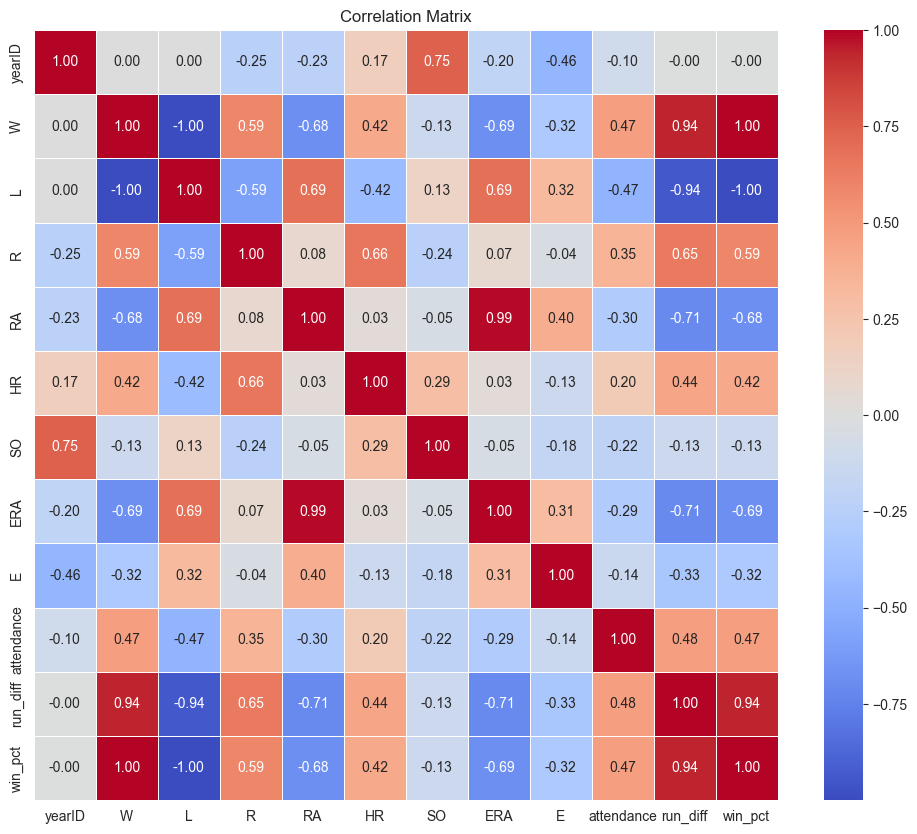

In [13]:
# Correlation Analysis - Correlation Matrix and Heatmap
corr = df.corr(numeric_only=True)
corr['W'].sort_values(ascending=False)

plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm', annot=True, fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()


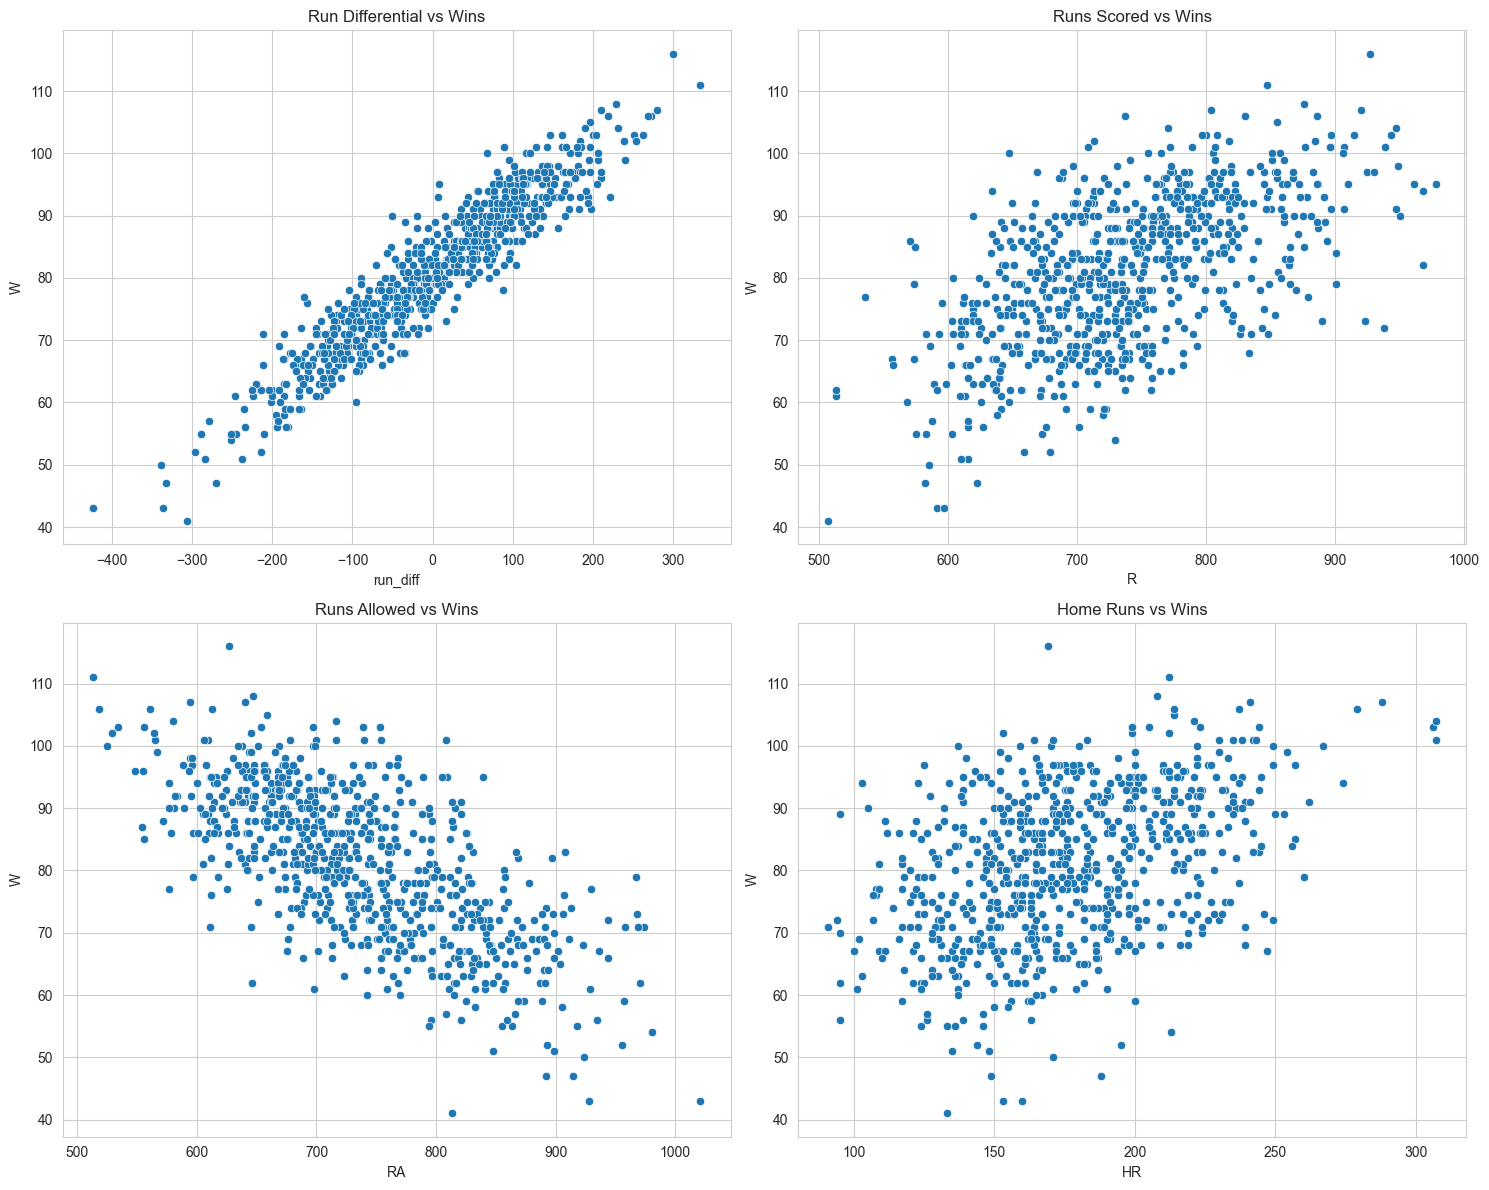

In [14]:
# Wins Analysis vs Runs Differential, Runs Scored, Runs Allowed, and Home Runs
fig, axes = plt.subplots(2, 2, figsize=(15,12))

# Chart 1 - Run Differential vs Wins
sns.scatterplot(data=df, x='run_diff', y='W', ax=axes[0,0])
axes[0,0].set_title('Run Differential vs Wins')

# Chart 2 - Runs Scored vs Wins
sns.scatterplot(data=df, x='R', y='W', ax=axes[0,1])
axes[0,1].set_title('Runs Scored vs Wins')

# Chart 3 - Runs Allowed vs Wins
sns.scatterplot(data=df, x='RA', y='W', ax=axes[1,0])
axes[1,0].set_title('Runs Allowed vs Wins')

# Chart 4 - Home Runs vs Wins
sns.scatterplot(data=df, x='HR', y='W', ax=axes[1,1])
axes[1,1].set_title('Home Runs vs Wins')

plt.tight_layout()
plt.show()

__Key Insight:__

Run Differential appears to be the strongest predictor of wins, while home runs alone are less predictive than total team performance.

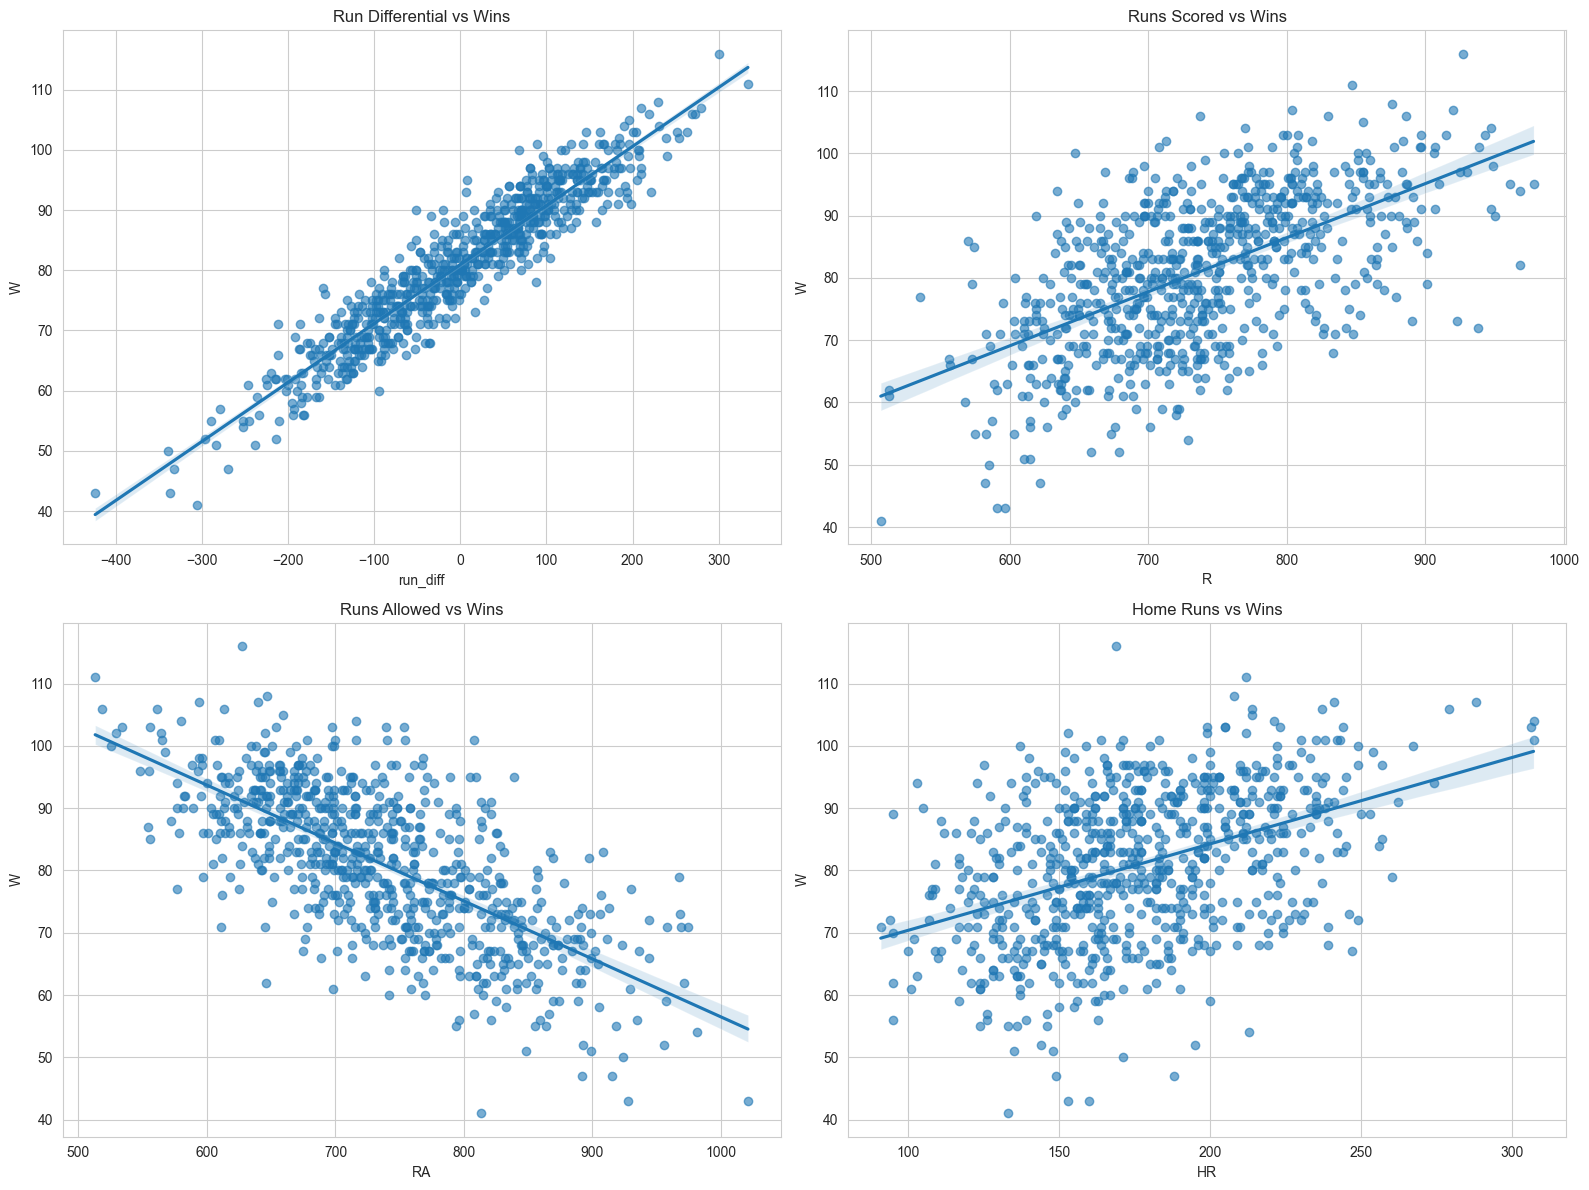

In [16]:
# Adding regression lines to the scatter plots
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sns.regplot(data=df, x="run_diff", y="W", ax=axes[0,0], scatter_kws={"alpha":0.6})
axes[0,0].set_title("Run Differential vs Wins")

sns.regplot(data=df, x="R", y="W", ax=axes[0,1], scatter_kws={"alpha":0.6})
axes[0,1].set_title("Runs Scored vs Wins")

sns.regplot(data=df, x="RA", y="W", ax=axes[1,0], scatter_kws={"alpha":0.6})
axes[1,0].set_title("Runs Allowed vs Wins")

sns.regplot(data=df, x="HR", y="W", ax=axes[1,1], scatter_kws={"alpha":0.6})
axes[1,1].set_title("Home Runs vs Wins")

plt.tight_layout()
plt.show()

In [17]:
# Best teams since 2000 based on wins
df.sort_values(by='W', ascending=False)[['yearID', 'teamID', 'W', 'run_diff']].head(10)

,yearID,teamID,W,run_diff
54,2001,SEA,116,300.0
643,2022,LAN,111,334.0
543,2018,BOS,108,229.0
580,2019,HOU,107,280.0
624,2021,SFN,107,210.0
583,2019,LAN,106,273.0
613,2021,LAN,106,269.0
640,2022,HOU,106,219.0
146,2004,SLN,105,196.0
661,2023,ATL,104,231.0


Good Future Analysis:
What separates elite teams?

In [ ]:
# Average HR by Year
hr_year = df.groupby('yearID')['HR'].mean().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=hr_year, x='yearID', y='HR')
plt.title("Total MLB Home Runs by Year")
plt.xlabel("Year")
plt.ylabel("Total HR")
plt.show()

ValueError: Per-column arrays must each be 1-dimensional

<Figure size 1200x600 with 0 Axes>